# ECC Model Analysis
Economic Carrying Capacity model with spatial land allocation.

**Run cells in order. Do not skip cells.**

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from datetime import datetime

from ecc_parameters import get_parameters
from ecc_optimization import ecc_optimization
from spatial_g import (
    load_spatial_data,
    get_kcal_per_ha,
    compute_effective_g,
    effective_par_from_g
)

print('imports ok')

imports ok


## 2. Load Spatial Data

In [2]:
PAR_grid, area, farmedPct, eimat, is_land = load_spatial_data()
area_ha = area / 10000

ei_mean = np.mean(eimat, axis=2)
is_land = (ei_mean > 0) & (farmedPct > 0)
print(f'farmable land cells: {is_land.sum()} of {180*360}')

print(f'PAR shape:       {PAR_grid.shape}')
print(f'area shape:      {area.shape}')
print(f'farmedPct shape: {farmedPct.shape}')
print(f'land cells:      {is_land.sum()} of {180*360}')
print(f'total area:      {np.nansum(area_ha)/1e9:.2f} Gha')
print(f'farmed area:     {np.nansum(farmedPct*area_ha)/1e9:.2f} Gha')
print(f'current farmed share: {np.nansum(farmedPct*area_ha)/np.nansum(area_ha):.4f}')

farmable land cells: 9598 of 64800
PAR shape:       (180, 360, 365)
area shape:      (180, 360)
farmedPct shape: (180, 360)
land cells:      9598 of 64800
total area:      51.01 Gha
farmed area:     4.21 Gha
current farmed share: 0.0825


## 3. Effective g vs Land Share
Shows how food productivity decreases as more land is brought into production.
At share=1.0, effective g converges to the all-land average matching the aspatial PAR scalar.

average PAR across all land: 106140403.47 kcal/ha/yr
aspatial g = 127262808 kcal/ha/yr

  share=0.05 -> g=173196703 kcal/ha/yr
  share=0.10 -> g=170899947 kcal/ha/yr
  share=0.15 -> g=168229263 kcal/ha/yr
  share=0.20 -> g=165685560 kcal/ha/yr
  share=0.25 -> g=163412064 kcal/ha/yr
  share=0.30 -> g=161569094 kcal/ha/yr
  share=0.35 -> g=159961062 kcal/ha/yr
  share=0.40 -> g=158412269 kcal/ha/yr
  share=0.45 -> g=156893863 kcal/ha/yr
  share=0.50 -> g=155428978 kcal/ha/yr
  share=0.55 -> g=153980304 kcal/ha/yr
  share=0.60 -> g=152528301 kcal/ha/yr
  share=0.65 -> g=151082965 kcal/ha/yr
  share=0.70 -> g=149593022 kcal/ha/yr
  share=0.75 -> g=148022568 kcal/ha/yr
  share=0.80 -> g=146314774 kcal/ha/yr
  share=0.85 -> g=144523655 kcal/ha/yr
  share=0.90 -> g=142511168 kcal/ha/yr
  share=0.95 -> g=139402392 kcal/ha/yr
  share=1.00 -> g=134584841 kcal/ha/yr


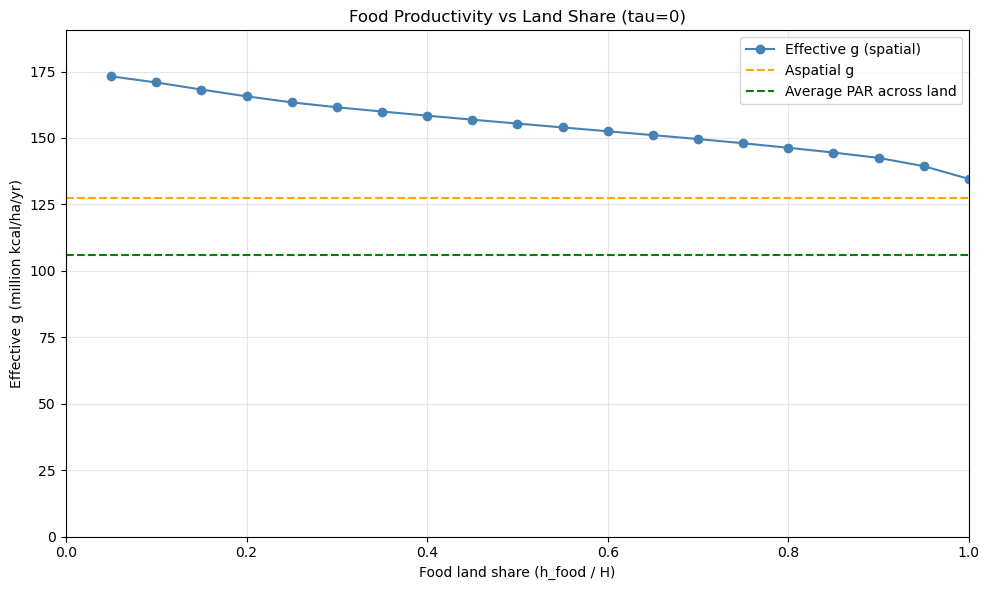

saved to effective_g_vs_share.png


In [3]:
tau = 0.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)

# average PAR across whole land area
avg_par = np.nansum(kcal_per_ha * area) / np.nansum(area)
print(f'average PAR across all land: {avg_par:.2f} kcal/ha/yr')

# aspatial reference
conversion = tau * (0.123 - 0.123/2.5) + 0.123/2.5
harvest    = 1 - (tau * (0 - 0.5) + 0.5)
g_aspatial = 2164.5 * 239.006 * 10000 * harvest * conversion

# full range 0 to 1
shares   = np.arange(0.05, 1.05, 0.05)
g_values = [compute_effective_g(kcal_per_ha, area_ha, farmedPct, s, is_land) for s in shares]

print(f'aspatial g = {g_aspatial:.0f} kcal/ha/yr')
print()
for s, g in zip(shares, g_values):
    print(f'  share={s:.2f} -> g={g:.0f} kcal/ha/yr')

plt.figure(figsize=(10, 6))
plt.axis([0, 1, 0, max(g_values) * 1.1 / 1e6])
plt.plot(shares, np.array(g_values) / 1e6, 'o-', color='steelblue', label='Effective g (spatial)')
plt.axhline(g_aspatial / 1e6, color='orange', linestyle='--', label='Aspatial g')
plt.axhline(avg_par / 1e6,    color='green',  linestyle='--', label='Average PAR across land')
plt.xlabel('Food land share (h_food / H)')
plt.ylabel('Effective g (million kcal/ha/yr)')
plt.title('Food Productivity vs Land Share (tau=0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('effective_g_vs_share.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to effective_g_vs_share.png')

## 4. Linear Fit to g vs Land Share

Linear fit: g(h_food) = 173472564 + -35544618 * h_food
R² = 0.9871
slope:     -35544617.70 kcal/ha/yr per unit share
intercept: 173472564.01 kcal/ha/yr
slope/intercept ratio: -0.204901


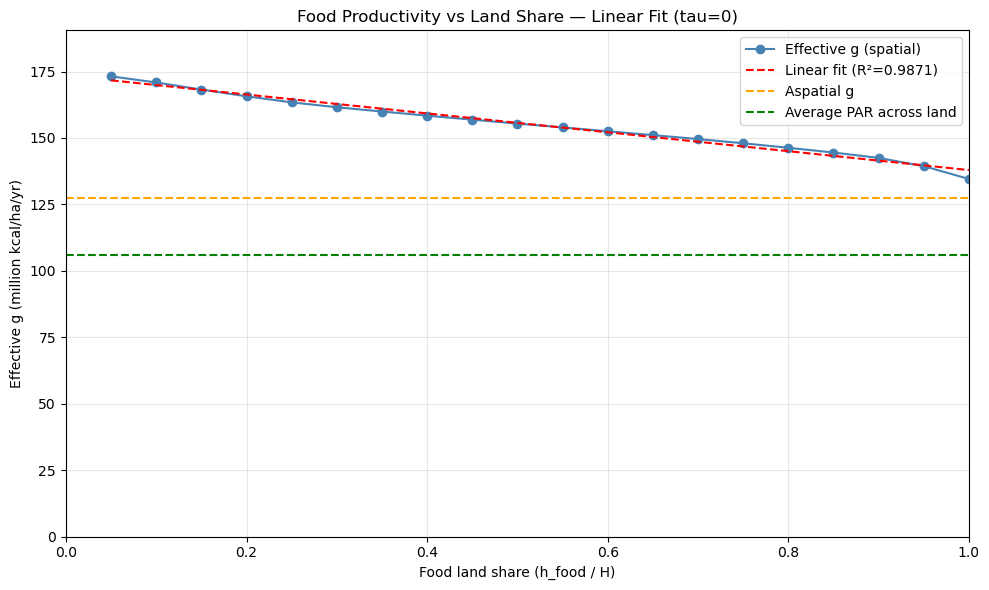

In [4]:
coeffs    = np.polyfit(shares, g_values, 1)
slope     = coeffs[0]
intercept = coeffs[1]
r_squared = np.corrcoef(shares, g_values)[0,1]**2

print(f'Linear fit: g(h_food) = {intercept:.0f} + {slope:.0f} * h_food')
print(f'R² = {r_squared:.4f}')
print(f'slope:     {slope:.2f} kcal/ha/yr per unit share')
print(f'intercept: {intercept:.2f} kcal/ha/yr')
print(f'slope/intercept ratio: {slope/intercept:.6f}')

g_fitted = np.polyval(coeffs, shares)

plt.figure(figsize=(10, 6))
plt.axis([0, 1, 0, max(g_values) * 1.1 / 1e6])
plt.plot(shares, np.array(g_values) / 1e6, 'o-', color='steelblue', label='Effective g (spatial)')
plt.plot(shares, g_fitted / 1e6, 'r--', label=f'Linear fit (R²={r_squared:.4f})')
plt.axhline(g_aspatial / 1e6, color='orange', linestyle='--', label='Aspatial g')
plt.axhline(avg_par / 1e6,    color='green',  linestyle='--', label='Average PAR across land')
plt.xlabel('Food land share (h_food / H)')
plt.ylabel('Effective g (million kcal/ha/yr)')
plt.title('Food Productivity vs Land Share — Linear Fit (tau=0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('effective_g_linear_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Aspatial Calibration Check

In [5]:
tau = 0.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
conversion = tau * (0.123 - 0.123/2.5) + 0.123/2.5
harvest    = 1 - (tau * (0 - 0.5) + 0.5)
g_aspatial = 2164.5 * 239.006 * 10000 * harvest * conversion

land_area  = area_ha * is_land
g_all_land = np.nansum(kcal_per_ha * land_area) / np.nansum(land_area)

farmed_area = farmedPct * area_ha * is_land
g_farmed    = np.nansum(kcal_per_ha * farmed_area) / np.nansum(farmed_area)

print('Aspatial calibration check (tau=0):')
print(f'  Aspatial g (PAR scalar): {g_aspatial:.0f} kcal/ha/yr')
print(f'  All-land weighted avg:   {g_all_land:.0f} kcal/ha/yr  (diff: {(g_all_land/g_aspatial-1)*100:.1f}%)')
print(f'  Farmed-land avg:         {g_farmed:.0f} kcal/ha/yr  (diff: {(g_farmed/g_aspatial-1)*100:.1f}%)')

Aspatial calibration check (tau=0):
  Aspatial g (PAR scalar): 127262808 kcal/ha/yr
  All-land weighted avg:   134584841 kcal/ha/yr  (diff: 5.8%)
  Farmed-land avg:         132887275 kcal/ha/yr  (diff: 4.4%)


## 6. Helper Functions
Must run before any optimization cells.

In [ ]:
def get_analytic_sols(params):
    mu0, mu1 = params['mu0'], params['mu1']
    g0,g1,g2,g3 = params['gamma0'],params['gamma1'],params['gamma2'],params['gamma3']
    a0,a1,a2    = params['alpha0'],params['alpha1'],params['alpha2']
    e0,e1       = params['eta0'],params['eta1']
    kd = a0*mu1 + mu0*g0 + e0*(mu0*g2 + mu1*a2)
    ld = a1*mu1 + mu0*g1 + e1*(mu0*g2 + mu1*a2)
    nd = mu0*g2 + mu1*a2
    hd = 1 + a2 + mu0*(g3 + g2 - 1 - a2)
    return np.array([
        g0*mu0/kd, a0*mu1/kd, e0*(mu0*g2+mu1*a2)/kd,
        g1*mu0/ld, a1*mu1/ld, e1*(mu0*g2+mu1*a2)/ld,
        mu0*g2/nd, mu1*a2/nd,
        mu0*g3/hd, mu1/hd, (mu0*g2+mu1*a2)/hd
    ])

def setup_params(pop, tau, params, sols, use_spatial=True,
                 kcal_per_ha=None, area_ha=None, farmedPct=None, is_land=None):
    p = params.copy()
    p['sols'] = sols
    L   = p['lfpr'] * pop
    ece = tau * (0.868 - 0.22) + 0.22
    if use_spatial:
        h_food = sols[9]
        eff_g  = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food, is_land)
        p['PAR'] = effective_par_from_g(eff_g, tau)
    nmax  = ece * p['PAR'] * sols[10] * (p['H']/L) * sols[2]**p['eta0'] * sols[5]**p['eta1']
    Omega = p['A'] * sols[0]**p['gamma0'] * sols[3]**p['gamma1'] * (sols[6]*nmax)**p['gamma2'] * (sols[8]*(p['H']/L))**p['gamma3']
    kmax  = (p['s']/p['d'] * Omega)**(1/(1-p['gamma0']))
    p['nmax'] = nmax
    p['kmax'] = kmax
    return p

def solve_one_point(tech, population, params, sols,
                    kcal_per_ha, area_ha, farmedPct, is_land,
                    max_iter=50, damping=0.6, track_convergence=False):
   
    p   = params.copy()
    p['sols'] = sols
    L   = p['lfpr'] * population
    ece = tech * (0.868 - 0.22) + 0.22

    h_food   = sols[9]
    eff_g    = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food, is_land)
    p['PAR'] = effective_par_from_g(eff_g, tech)

    nmax  = ece * p['PAR'] * sols[10] * (p['H']/L) * sols[2]**p['eta0'] * sols[5]**p['eta1']
    Omega = p['A'] * sols[0]**p['gamma0'] * sols[3]**p['gamma1'] * (sols[6]*nmax)**p['gamma2'] * (sols[8]*(p['H']/L))**p['gamma3']
    kmax  = (p['s']/p['d'] * Omega)**(1/(1-p['gamma0']))
    p['nmax'] = nmax
    p['kmax'] = kmax

    tolerance    = 1e-4 if L <= 1 else 1e-5 * max(1, population/25)
    eff_g_history = [eff_g]

    for iter_num in range(max_iter):
        try:
            soltemp, utiltemp, exitflag = ecc_optimization(population, tech, p)
        except:
            if track_convergence:
                return np.full(11, -np.inf), -np.inf, -1, eff_g_history
            return np.full(11, -np.inf), -np.inf, -1

        if exitflag == -2:
            if track_convergence:
                return np.full(11, np.nan), np.nan, -2, eff_g_history
            return np.full(11, np.nan), np.nan, -2
        elif exitflag <= 0:
            if track_convergence:
                return np.full(11, -np.inf), -np.inf, exitflag, eff_g_history
            return np.full(11, -np.inf), -np.inf, exitflag

        h_food_new = soltemp[9]
        eff_g_new  = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food_new, is_land)
        p['PAR']   = effective_par_from_g(eff_g_new, tech)

        y_imp    = p['A'] * (soltemp[0]*kmax)**p['gamma0'] * soltemp[3]**p['gamma1'] * (soltemp[6]*nmax)**p['gamma2'] * (soltemp[8]*(p['H']/L))**p['gamma3']
        kmax_imp = p['s']/p['d'] * y_imp
        nmax_imp = ece * p['PAR'] * soltemp[10] * (p['H']/L) * (soltemp[2]*kmax/kmax_imp)**p['eta0'] * soltemp[5]**p['eta1']

        error_k = abs(kmax_imp - p['kmax'])
        error_n = abs(nmax_imp - p['nmax'])
        error_g = abs(eff_g_new - eff_g)

        eff_g_history.append(eff_g_new)

        if error_k < tolerance and error_n < tolerance and error_g < 1.0:
            if track_convergence:
                return soltemp, utiltemp, 1, eff_g_history
            return soltemp, utiltemp, 1

        p['kmax'] = damping*kmax_imp + (1-damping)*p['kmax']
        p['nmax'] = damping*nmax_imp + (1-damping)*p['nmax']
        eff_g     = eff_g_new
        kmax      = p['kmax']
        nmax      = p['nmax']

    if track_convergence:
        return np.full(11, np.inf), np.inf, 0, eff_g_history
    return np.full(11, np.inf), np.inf, 0

print('helper functions defined')

helper functions defined


## 7. Convergence Test for eff_g

In [7]:
tau = 0.0
pop = 8.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
params = get_parameters()
sols   = get_analytic_sols(params)

sol_s, util_s, flag_s, eff_g_hist = solve_one_point(
    tau, pop, params, sols,
    kcal_per_ha, area_ha, farmedPct, is_land,
    max_iter=50, track_convergence=True
)

print(f'exitflag: {flag_s}')
print(f'converged in {len(eff_g_hist)} iterations')
print(f'eff_g history:')
for i, g in enumerate(eff_g_hist):
    print(f'  iter {i}: eff_g = {g:.0f}')

exitflag: 1
converged in 24 iterations
eff_g history:
  iter 0: eff_g = 168544987
  iter 1: eff_g = 164938030
  iter 2: eff_g = 164847635
  iter 3: eff_g = 164849927
  iter 4: eff_g = 164852162
  iter 5: eff_g = 164853204
  iter 6: eff_g = 164853689
  iter 7: eff_g = 164853920
  iter 8: eff_g = 164854032
  iter 9: eff_g = 164854091
  iter 10: eff_g = 164854120
  iter 11: eff_g = 164854136
  iter 12: eff_g = 164854145
  iter 13: eff_g = 164854150
  iter 14: eff_g = 164854152
  iter 15: eff_g = 164854153
  iter 16: eff_g = 164854155
  iter 17: eff_g = 164854155
  iter 18: eff_g = 164854154
  iter 19: eff_g = 164854156
  iter 20: eff_g = 164854156
  iter 21: eff_g = 164854156
  iter 22: eff_g = 164854155
  iter 23: eff_g = 164854156


## 8. Single Point Test — Spatial vs Aspatial (tau=0, pop=8B)

In [8]:
tau = 0.0
pop = 8.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
params = get_parameters()
sols   = get_analytic_sols(params)

# spatial
p_spatial = setup_params(pop, tau, params, sols, use_spatial=True,
                         kcal_per_ha=kcal_per_ha, area_ha=area_ha,
                         farmedPct=farmedPct, is_land=is_land)
sol_s, util_s, flag_s = ecc_optimization(pop, tau, p_spatial)

# aspatial
p_aspatial = setup_params(pop, tau, params, sols, use_spatial=False)
sol_a, util_a, flag_a = ecc_optimization(pop, tau, p_aspatial)

H         = params['H'] * 1e9
farmed_ha = np.nansum(farmedPct * area_ha)

print(f'tau={tau}, pop={pop}B')
print(f'  Spatial:  exitflag={flag_s}, utility={-util_s:.6f}, h_food={sol_s[9]:.4f}')
print(f'  Aspatial: exitflag={flag_a}, utility={-util_a:.6f}, h_food={sol_a[9]:.4f}')
print(f'  Utility difference: {(-util_s/(-util_a)-1)*100:.2f}%')
print()
print(f'Land use breakdown:')
print(f'  H (total model land):   {H/1e9:.3f} Gha')
print(f'  food land spatial:      {sol_s[9]*H/1e9:.3f} Gha ({sol_s[9]*100:.1f}% of H)')
print(f'  food land aspatial:     {sol_a[9]*H/1e9:.3f} Gha ({sol_a[9]*100:.1f}% of H)')
print(f'  current farmed area:    {farmed_ha/1e9:.3f} Gha')
print(f'  spatial uses {sol_s[9]*H/farmed_ha*100:.1f}% of current farmed area')
print(f'  aspatial uses {sol_a[9]*H/farmed_ha*100:.1f}% of current farmed area')

tau=0.0, pop=8.0B
  Spatial:  exitflag=1, utility=7.413301, h_food=0.2154
  Aspatial: exitflag=1, utility=7.244839, h_food=0.2438
  Utility difference: 2.33%

Land use breakdown:
  H (total model land):   4.913 Gha
  food land spatial:      1.058 Gha (21.5% of H)
  food land aspatial:     1.198 Gha (24.4% of H)
  current farmed area:    4.206 Gha
  spatial uses 25.2% of current farmed area
  aspatial uses 28.5% of current farmed area


## 9. Income and Substitution Effects

In [9]:
# re-run explicitly at tau=0, pop=8 to avoid variable contamination
tau = 0.0
pop = 8.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
params = get_parameters()
sols   = get_analytic_sols(params)
p_spatial  = setup_params(pop, tau, params, sols, use_spatial=True,
                          kcal_per_ha=kcal_per_ha, area_ha=area_ha,
                          farmedPct=farmedPct, is_land=is_land)
p_aspatial = setup_params(pop, tau, params, sols, use_spatial=False)
sol_s, util_s, flag_s = ecc_optimization(pop, tau, p_spatial)
sol_a, util_a, flag_a = ecc_optimization(pop, tau, p_aspatial)

H = params['H'] * 1e9
conversion = tau * (0.123 - 0.123/2.5) + 0.123/2.5
harvest    = 1 - (tau * (0 - 0.5) + 0.5)
g_s = effective_par_from_g(
    compute_effective_g(kcal_per_ha, area_ha, farmedPct, sol_s[9], is_land), tau
) * 239.006 * 10000 * harvest * conversion
g_a = 2164.5 * 239.006 * 10000 * harvest * conversion

print(f'tau={tau}, pop={pop}B')
print(f'  Spatial:  exitflag={flag_s}, utility={-util_s:.6f}, h_food={sol_s[9]:.4f}')
print(f'  Aspatial: exitflag={flag_a}, utility={-util_a:.6f}, h_food={sol_a[9]:.4f}')
print()
print(f'Land allocated to food:')
print(f'  Spatial:  {sol_s[9]*H/1e9:.3f} Gha ({sol_s[9]*100:.1f}% of H)')
print(f'  Aspatial: {sol_a[9]*H/1e9:.3f} Gha ({sol_a[9]*100:.1f}% of H)')
print(f'  Change:   {(sol_s[9]/sol_a[9] - 1)*100:.1f}%')
print()
print(f'Land allocated to goods:')
print(f'  Spatial:  {sol_s[8]*H/1e9:.3f} Gha ({sol_s[8]*100:.1f}% of H)')
print(f'  Aspatial: {sol_a[8]*H/1e9:.3f} Gha ({sol_a[8]*100:.1f}% of H)')
print(f'  Change:   {(sol_s[8]/sol_a[8] - 1)*100:.1f}%')
print()
print(f'Relative calorie production proxy (g x h_food):')
print(f'  Spatial:  {g_s * sol_s[9]:.4e}')
print(f'  Aspatial: {g_a * sol_a[9]:.4e}')
print(f'  Ratio:    {(g_s * sol_s[9]) / (g_a * sol_a[9]):.4f}')
print()
print(f'Predictions:')
print(f'  More calories (g x h_food higher): {(g_s * sol_s[9]) > (g_a * sol_a[9])}')
print(f'  Less food land:                    {sol_s[9] < sol_a[9]}')
print(f'  More goods land:                   {sol_s[8] > sol_a[8]}')
print(f'  Utility higher spatial:            {-util_s > -util_a}')
print()
print(f'Summary:')
print(f'  Utility difference:   {(-util_s/(-util_a)-1)*100:.2f}%')
print(f'  Food land change:     {(sol_s[9]/sol_a[9] - 1)*100:.1f}%')
print(f'  Goods land change:    {(sol_s[8]/sol_a[8] - 1)*100:.1f}%')
print(f'  Calorie proxy change: {((g_s*sol_s[9])/(g_a*sol_a[9]) - 1)*100:.1f}%')

tau=0.0, pop=8.0B
  Spatial:  exitflag=1, utility=7.413301, h_food=0.2154
  Aspatial: exitflag=1, utility=7.244839, h_food=0.2438

Land allocated to food:
  Spatial:  1.058 Gha (21.5% of H)
  Aspatial: 1.198 Gha (24.4% of H)
  Change:   -11.7%

Land allocated to goods:
  Spatial:  2.118 Gha (43.1% of H)
  Aspatial: 2.037 Gha (41.5% of H)
  Change:   4.0%

Relative calorie production proxy (g x h_food):
  Spatial:  3.5523e+07
  Aspatial: 3.1027e+07
  Ratio:    1.1449

Predictions:
  More calories (g x h_food higher): True
  Less food land:                    True
  More goods land:                   True
  Utility higher spatial:            True

Summary:
  Utility difference:   2.33%
  Food land change:     -11.7%
  Goods land change:    4.0%
  Calorie proxy change: 14.5%


## 10. Food Productivity Map

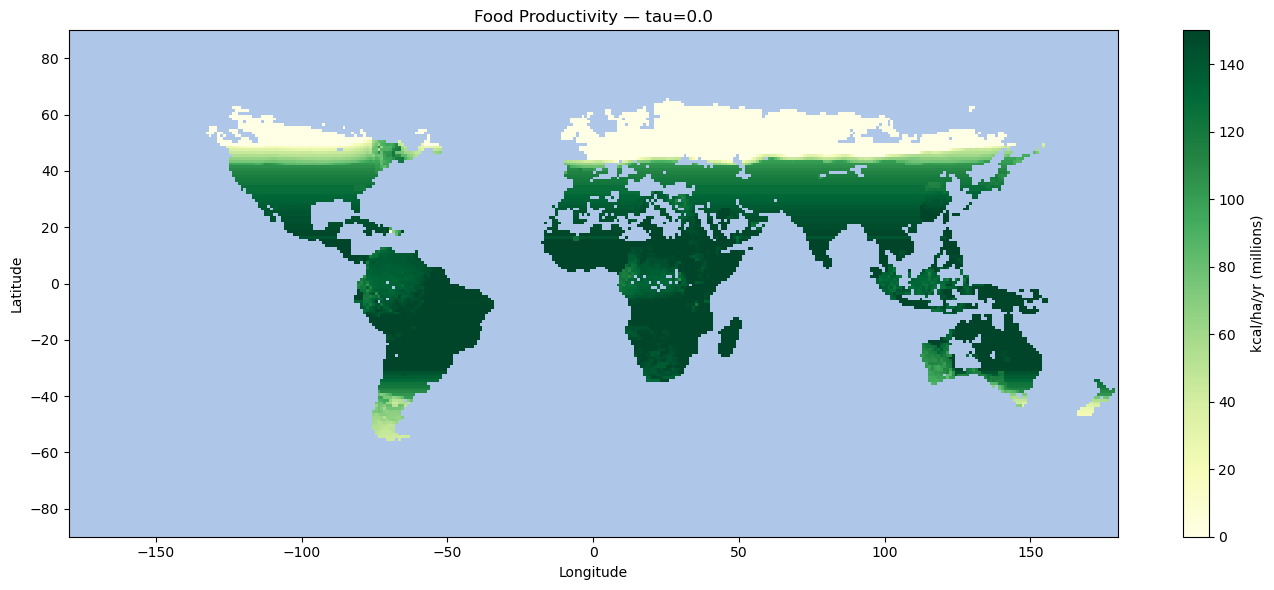

saved to food_productivity_map.png


In [10]:
lon   = np.linspace(-179.5, 179.5, 360)
lat   = np.linspace(89.5, -89.5, 180)
lon2d, lat2d = np.meshgrid(lon, lat)

tau = 0.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
g_masked = np.where(farmedPct > 0, kcal_per_ha, np.nan)

plt.figure(figsize=(14, 6))
im = plt.pcolormesh(lon2d, lat2d, g_masked/1e6, cmap='YlGn', shading='auto', vmin=0, vmax=150)
plt.colorbar(im, label='kcal/ha/yr (millions)')
plt.title(f'Food Productivity — tau={tau}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.gca().set_facecolor('#aec6e8')
plt.tight_layout()
plt.savefig('food_productivity_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to food_productivity_map.png')

## 11. Land Allocation Map
Change tau and pop at the top to explore different scenarios.

tau=1.0, pop=8.0B: exitflag=1, utility=8.2229, h_food=0.1439


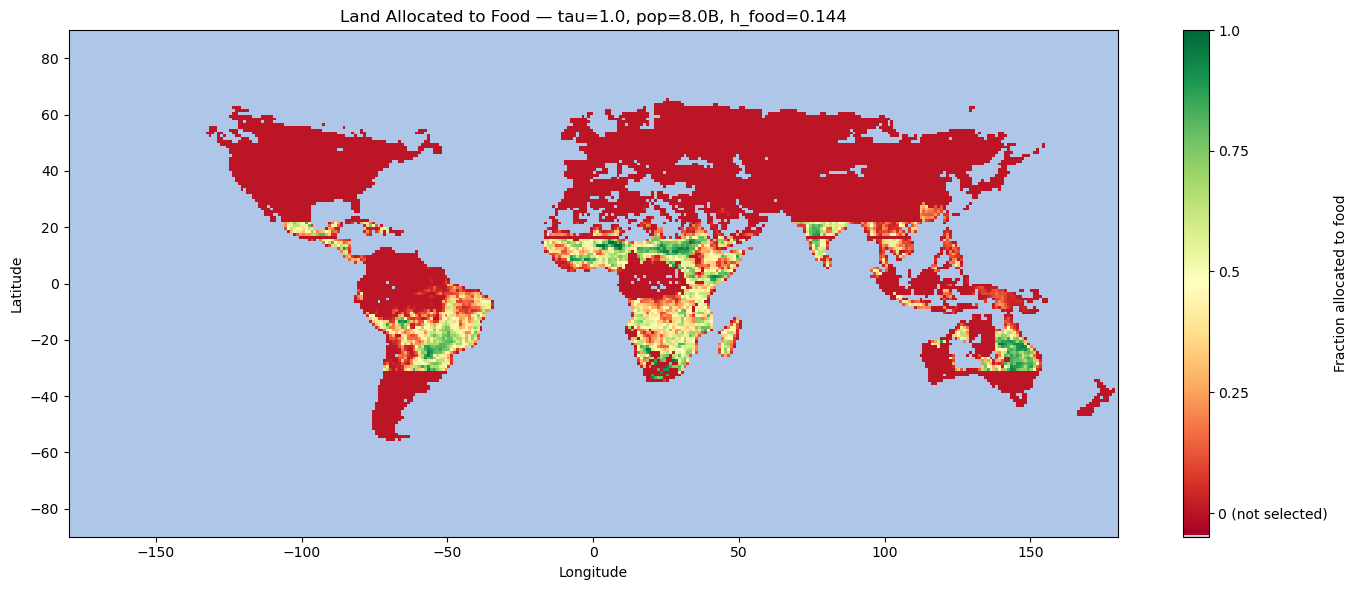

saved to land_allocation_tau1.0_pop8.png


In [11]:
# change these to explore scenarios
tau = 1.0
pop = 8.0
# -----------------------------------------

kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
params_map = get_parameters()
sols_map   = get_analytic_sols(params_map)
p_map      = setup_params(pop, tau, params_map, sols_map, use_spatial=True,
                          kcal_per_ha=kcal_per_ha, area_ha=area_ha,
                          farmedPct=farmedPct, is_land=is_land)
sol_map, util_map, flag_map = ecc_optimization(pop, tau, p_map)
h_food_share = sol_map[9]

print(f'tau={tau}, pop={pop}B: exitflag={flag_map}, utility={-util_map:.4f}, h_food={h_food_share:.4f}')

g_flat      = kcal_per_ha.ravel()
area_flat   = area_ha.ravel()
farmed_flat = farmedPct.ravel()
land_flat   = is_land.ravel()
farmable    = (farmed_flat > 0) & land_flat
unfarmed_land = (farmed_flat == 0) & land_flat
total_land_ha = np.nansum(area_flat * land_flat)
target_ha     = h_food_share * total_land_ha
farmed_area   = farmed_flat * area_flat * farmable
unfarmed_area = area_flat * unfarmed_land
order         = np.argsort(-g_flat)
selected      = np.zeros(len(g_flat))
accumulated   = 0.0

for idx in order:
    if farmed_area[idx] <= 0: continue
    if accumulated >= target_ha: break
    take = min(farmed_area[idx], target_ha - accumulated)
    selected[idx] = take / area_flat[idx]
    accumulated  += take

for idx in order:
    if unfarmed_area[idx] <= 0: continue
    if accumulated >= target_ha: break
    take = min(unfarmed_area[idx], target_ha - accumulated)
    selected[idx] = take / area_flat[idx]
    accumulated  += take

selected_2d = selected.reshape(180, 360)
display_2d  = np.where(farmedPct > 0, selected_2d,
              np.where(is_land, -0.05, np.nan))
colors_list = ['#d3d3d3'] + list(plt.cm.RdYlGn(np.linspace(0, 1, 256)))
custom_cmap = LinearSegmentedColormap.from_list('grey_RdYlGn', colors_list, N=257)

plt.figure(figsize=(14, 6))
im = plt.pcolormesh(lon2d, lat2d, display_2d, cmap=custom_cmap, shading='auto', vmin=-0.05, vmax=1)
cbar = plt.colorbar(im, label='Fraction allocated to food')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0 (not selected)', '0.25', '0.5', '0.75', '1.0'])
plt.title(f'Land Allocated to Food — tau={tau}, pop={pop}B, h_food={h_food_share:.3f}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.gca().set_facecolor('#aec6e8')
plt.tight_layout()
plt.savefig(f'land_allocation_tau{tau}_pop{int(pop)}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'saved to land_allocation_tau{tau}_pop{int(pop)}.png')

## 12. Small Grid Run — Spatial vs Aspatial
This will take ~20-30 minutes. Can be run seperately/out of order

In [ ]:
import time
tau_grid = np.arange(1.0, 0.0, -0.1)
pop_grid = np.arange(1, 202, 20).astype(float)

params = get_parameters()
sols   = get_analytic_sols(params)

n_tau = len(tau_grid)
n_pop = len(pop_grid)
total = n_tau * n_pop
print(f'grid: {n_tau} tau x {n_pop} pop = {total} problems')

utilmat_spatial  = np.full((n_tau, n_pop), np.nan)
utilmat_aspatial = np.full((n_tau, n_pop), np.nan)

start     = time.time()
completed = 0

for k, tech in enumerate(tau_grid):
    kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tech)
    for j, population in enumerate(pop_grid):
        # spatial (returns 3 values)
        sol_sp, util_sp, flag_sp = solve_one_point(
            tech, population, params, sols,
            kcal_per_ha, area_ha, farmedPct, is_land
        )
        if flag_sp == 1:
            utilmat_spatial[k, j] = -util_sp

        # aspatial
        p_a = setup_params(population, tech, params, sols, use_spatial=False)
        sol_asp, util_asp, flag_asp = ecc_optimization(population, tech, p_a)
        if flag_asp == 1:
            utilmat_aspatial[k, j] = -util_asp

        completed += 1
        if completed % 10 == 0 or completed == total:
            elapsed = time.time() - start
            print(f'  {completed}/{total} done | {elapsed:.0f}s | {elapsed/completed:.1f}s/problem', flush=True)

print(f'done — total time: {time.time()-start:.0f}s')

## 13. Heatmap Comparison

In [ ]:
def make_heatmap(utilmat, tau, pop, title, ax):
    plotdata = utilmat.copy()
    finite_mask = np.isfinite(plotdata)
    if not np.any(finite_mask):
        ax.set_title(f'{title} — no finite values')
        return
    actual_min = np.nanmin(plotdata[finite_mask])
    actual_max = np.nanmax(plotdata[finite_mask])
    plotdata[np.isinf(plotdata)] = actual_min - 1
    jet    = plt.cm.jet
    colors = [[1,1,1]] + jet(np.linspace(0,1,256)).tolist()
    cmap   = LinearSegmentedColormap.from_list('custom', colors)
    Pop, Tau = np.meshgrid(pop, tau)
    im = ax.pcolormesh(Pop, Tau, plotdata, cmap=cmap, shading='auto')
    im.set_clim(actual_min-1, actual_max)
    ax.set_facecolor('black')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel('Population (billions)')
    ax.set_ylabel('Technology Level (τ)')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
make_heatmap(utilmat_spatial,  tau_grid, pop_grid, 'Spatial Model',  axes[0])
make_heatmap(utilmat_aspatial, tau_grid, pop_grid, 'Aspatial Model', axes[1])
plt.suptitle('Utility Heatmap Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to heatmap_comparison.png')

## 14. Save Results

In [ ]:
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
filename  = f'ECC_notebook_results_{timestamp}.npz'
np.savez_compressed(
    filename,
    utilmat_spatial=utilmat_spatial,
    utilmat_aspatial=utilmat_aspatial,
    tau=tau_grid,
    pop=pop_grid
)
print(f'saved to {filename}')

## 15. Water Flux Integration
Testing the effect of incorporating water availability and irrigation into food productivity.

In [12]:
import scipy.io as sio
from spatial_g_water import (
    load_spatial_data as load_spatial_data_water,
    get_kcal_per_ha as get_kcal_per_ha_water,
    compute_effective_g,
    effective_par_from_g
)

# load all spatial data including water — stored with _w suffix to avoid overwriting
(PAR_w, area_w, farmedPct_w, eimat_w,
 waterflux_w, irrigatedPct_w, is_land_w) = load_spatial_data_water()
area_ha_w = area_w / 10000

ei_mean_w  = np.mean(eimat_w, axis=2)
is_land_w  = (ei_mean_w > 0) & (farmedPct_w > 0)

print(f'PAR shape:          {PAR_w.shape}')
print(f'waterflux shape:    {waterflux_w.shape}')
print(f'irrigatedPct shape: {irrigatedPct_w.shape}')
print(f'farmable cells:     {is_land_w.sum()} of {180*360}')
print(f'total area:         {np.nansum(area_ha_w)/1e9:.2f} Gha')
print(f'farmed area:        {np.nansum(farmedPct_w*area_ha_w)/1e9:.2f} Gha')
print(f'irrigated area:     {np.nansum(irrigatedPct_w*farmedPct_w*area_ha_w)/1e9:.2f} Gha')

PAR shape:          (180, 360, 365)
waterflux shape:    (180, 360, 365)
irrigatedPct shape: (180, 360)
farmable cells:     9598 of 64800
total area:         51.01 Gha
farmed area:        4.21 Gha
irrigated area:     0.30 Gha


In [13]:
# compare potential vs rainfed vs irrigated productivity
tau_w = 0.0

kcal_potential_w, _ = get_kcal_per_ha_water(PAR_w, eimat_w, area_w, tau_w)
kcal_rainfed_w, _   = get_kcal_per_ha_water(PAR_w, eimat_w, area_w, tau_w,
                                              waterflux_w, irrigatedPct_w,
                                              use_irrigation=False)
kcal_irrigated_w, _ = get_kcal_per_ha_water(PAR_w, eimat_w, area_w, tau_w,
                                              waterflux_w, irrigatedPct_w,
                                              use_irrigation=True)

print(f'Productivity comparison (tau={tau_w}, farmable cells only):')
print(f'  Potential (no water limit): {np.nanmean(kcal_potential_w[is_land_w])/1e6:.1f}M kcal/ha/yr')
print(f'  Rainfed:                    {np.nanmean(kcal_rainfed_w[is_land_w])/1e6:.1f}M kcal/ha/yr')
print(f'  Irrigated:                  {np.nanmean(kcal_irrigated_w[is_land_w])/1e6:.1f}M kcal/ha/yr')
print(f'  Rainfed reduction:          {(1 - np.nanmean(kcal_rainfed_w[is_land_w])/np.nanmean(kcal_potential_w[is_land_w]))*100:.1f}%')
print(f'  Irrigation benefit:         {(np.nanmean(kcal_irrigated_w[is_land_w])/np.nanmean(kcal_rainfed_w[is_land_w])-1)*100:.1f}%')
print(f'  Aspatial g (reference):     127.3M kcal/ha/yr')

Productivity comparison (tau=0.0, farmable cells only):
  Potential (no water limit): 131.6M kcal/ha/yr
  Rainfed:                    34.9M kcal/ha/yr
  Irrigated:                  39.1M kcal/ha/yr
  Rainfed reduction:          73.5%
  Irrigation benefit:         12.1%
  Aspatial g (reference):     127.3M kcal/ha/yr


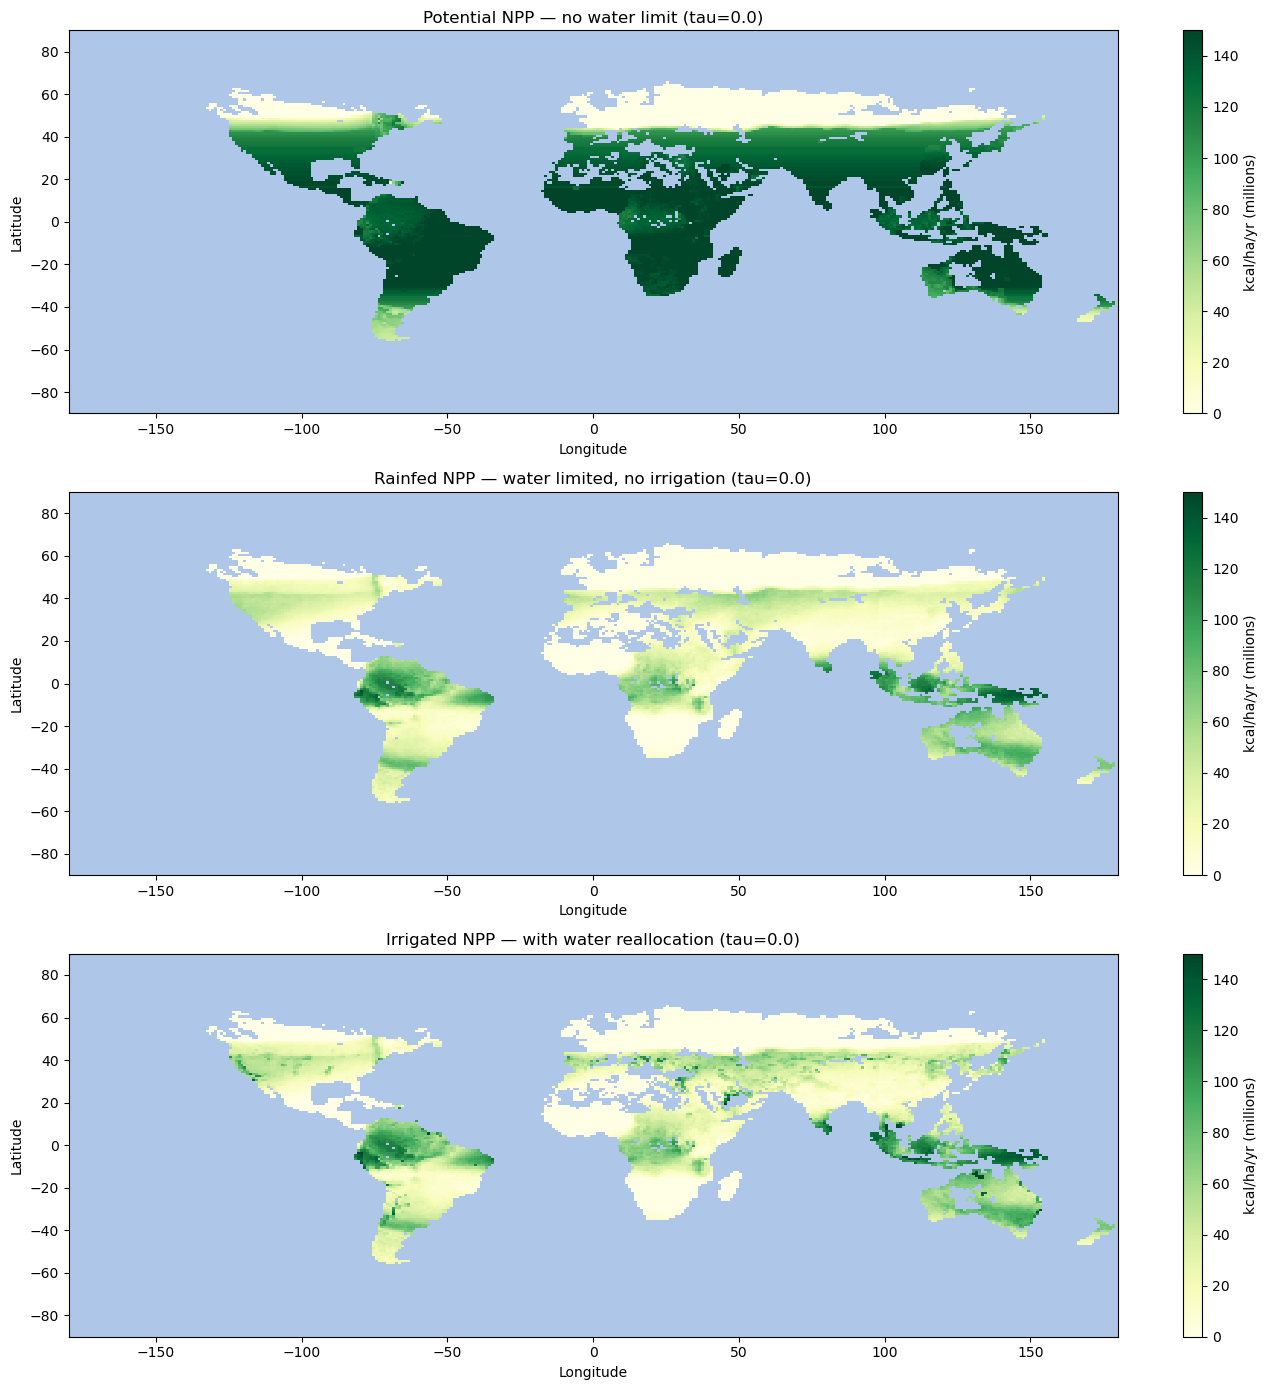

saved to productivity_comparison_water.png


In [14]:
# map comparison: potential vs rainfed vs irrigated
lon_w   = np.linspace(-179.5, 179.5, 360)
lat_w   = np.linspace(89.5, -89.5, 180)
lon2d_w, lat2d_w = np.meshgrid(lon_w, lat_w)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, data, title in [
    (axes[0], kcal_potential_w, f'Potential NPP — no water limit (tau={tau_w})'),
    (axes[1], kcal_rainfed_w,   f'Rainfed NPP — water limited, no irrigation (tau={tau_w})'),
    (axes[2], kcal_irrigated_w, f'Irrigated NPP — with water reallocation (tau={tau_w})'),
]:
    g_plot = np.where(farmedPct_w > 0, data, np.nan)
    im = ax.pcolormesh(lon2d_w, lat2d_w, g_plot/1e6, cmap='YlGn', shading='auto', vmin=0, vmax=150)
    plt.colorbar(im, ax=ax, label='kcal/ha/yr (millions)')
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_facecolor('#aec6e8')

plt.tight_layout()
plt.savefig('productivity_comparison_water.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to productivity_comparison_water.png')

In [15]:
# single point test with irrigation vs potential vs aspatial
tau_w = 0.0
pop_w = 8.0

params_w = get_parameters()
sols_w   = get_analytic_sols(params_w)

# spatial with irrigation
p_irr = setup_params(pop_w, tau_w, params_w, sols_w, use_spatial=True,
                     kcal_per_ha=kcal_irrigated_w, area_ha=area_ha_w,
                     farmedPct=farmedPct_w, is_land=is_land_w)
sol_irr, util_irr, flag_irr = ecc_optimization(pop_w, tau_w, p_irr)

# spatial potential (no water)
p_pot = setup_params(pop_w, tau_w, params_w, sols_w, use_spatial=True,
                     kcal_per_ha=kcal_potential_w, area_ha=area_ha_w,
                     farmedPct=farmedPct_w, is_land=is_land_w)
sol_pot, util_pot, flag_pot = ecc_optimization(pop_w, tau_w, p_pot)

# aspatial
p_asp = setup_params(pop_w, tau_w, params_w, sols_w, use_spatial=False)
sol_asp, util_asp, flag_asp = ecc_optimization(pop_w, tau_w, p_asp)

H_w = params_w['H'] * 1e9
print(f'tau={tau_w}, pop={pop_w}B')
print()
print(f'  Spatial irrigated: exitflag={flag_irr}, utility={-util_irr:.6f}, h_food={sol_irr[9]:.4f}')
print(f'  Spatial potential: exitflag={flag_pot}, utility={-util_pot:.6f}, h_food={sol_pot[9]:.4f}')
print(f'  Aspatial:          exitflag={flag_asp}, utility={-util_asp:.6f}, h_food={sol_asp[9]:.4f}')
print()
print(f'Utility vs aspatial:')
print(f'  Spatial irrigated: {(-util_irr/(-util_asp)-1)*100:.2f}%')
print(f'  Spatial potential: {(-util_pot/(-util_asp)-1)*100:.2f}%')
print()
print(f'Food land:')
print(f'  Spatial irrigated: {sol_irr[9]*H_w/1e9:.3f} Gha')
print(f'  Spatial potential: {sol_pot[9]*H_w/1e9:.3f} Gha')
print(f'  Aspatial:          {sol_asp[9]*H_w/1e9:.3f} Gha')

tau=0.0, pop=8.0B

  Spatial irrigated: exitflag=1, utility=7.099007, h_food=0.2701
  Spatial potential: exitflag=1, utility=7.413301, h_food=0.2154
  Aspatial:          exitflag=1, utility=7.244839, h_food=0.2438

Utility vs aspatial:
  Spatial irrigated: -2.01%
  Spatial potential: 2.33%

Food land:
  Spatial irrigated: 1.327 Gha
  Spatial potential: 1.058 Gha
  Aspatial:          1.198 Gha
